In [43]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np


In [44]:
seq = torch.tensor([1,2,3,4,5,6,7,8], dtype=torch.float32)
X = seq[:-1].unsqueeze(-1).unsqueeze(0)
Y = seq[1:].unsqueeze(-1).unsqueeze(0)


## Simple RNN Definition

In [45]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        out, h = self.rnn(x)
        out = self.fc(out)
        return out

model = SimpleRNN(1, 16, 1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


## Training Simple RNN

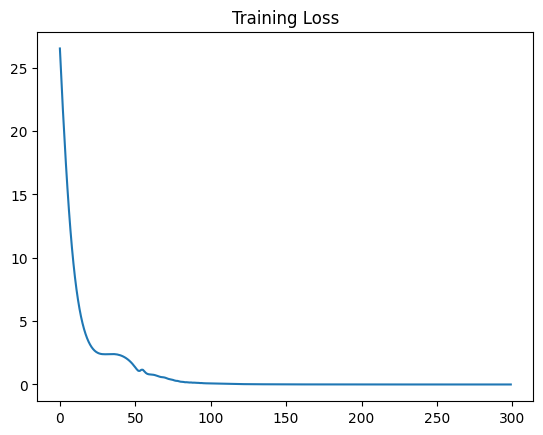

In [46]:
losses = []
for epoch in range(300):
    optimizer.zero_grad()
    output = model(X)
    loss = criterion(output, Y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.plot(losses)
plt.title("Training Loss")
plt.show()


## RNN with ReLU Activation

In [47]:
class RNN_ReLU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, nonlinearity='relu', batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out)

model_relu = RNN_ReLU(1, 16, 1)


## Fibonacci Dataset

In [48]:
def fibonacci(n=200):
    seq = [0, 1]
    for _ in range(n - 2):
        next_fib = seq[-1] + seq[-2]
        # Cap at a large but finite number to prevent float32 overflow (e.g., 1e30 is well within float32 max)
        if next_fib > 1e30:
            next_fib = 1e30
        seq.append(next_fib)

    seq_np = np.array(seq, dtype=np.float32)

    # Normalize to [0, 1] range using min-max scaling
    min_val = seq_np.min()
    max_val = seq_np.max()

    if max_val - min_val > 0:
        normalized_seq = (seq_np - min_val) / (max_val - min_val)
    else:
        # If all elements are the same (e.g., all zeros or all capped values are identical)
        normalized_seq = np.zeros_like(seq_np) if min_val == 0 else np.ones_like(seq_np)

    return normalized_seq

def create_dataset_fib(seq, seq_len=10):
    X, Y = [], []
    for i in range(len(seq) - seq_len):
        X.append(seq[i : i + seq_len])
        Y.append(seq[i + seq_len])
    return torch.tensor(X).unsqueeze(-1), torch.tensor(Y).unsqueeze(-1)

fib = fibonacci(300)
X_fib, Y_fib = create_dataset_fib(fib)

## Train RNN on Fibonacci

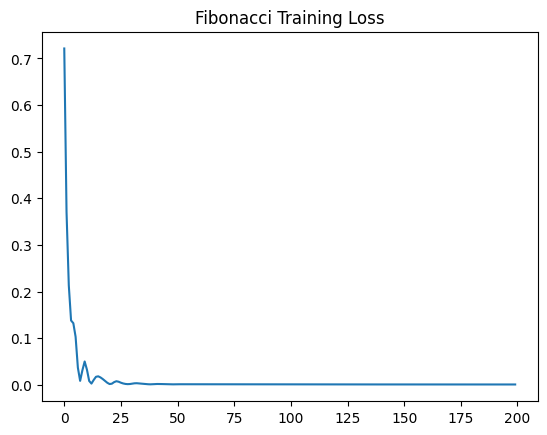

In [49]:
model_fib = SimpleRNN(1, 32, 1)
opt_fib = optim.Adam(model_fib.parameters(), lr=0.01)
crit = nn.MSELoss()
losses_fib = []

for epoch in range(200):
    opt_fib.zero_grad()
    out = model_fib(X_fib.float())
    loss = crit(out[:, -1, :], Y_fib.float())
    loss.backward()
    opt_fib.step()
    losses_fib.append(loss.item())

plt.plot(losses_fib)
plt.title("Fibonacci Training Loss")
plt.show()


## Visualize Hidden State

In [50]:
rnn_layer = model_fib.rnn
with torch.no_grad():
    sample = X_fib[:1].float()
    out, hidden = rnn_layer(sample)
    print(hidden)


tensor([[[ 0.0770,  0.1870,  0.0512,  0.2245,  0.0262,  0.0316,  0.0090,
           0.2376,  0.0307,  0.1869, -0.2696, -0.0367,  0.0433,  0.0369,
           0.0032, -0.1111, -0.0569, -0.0263,  0.2061, -0.0559,  0.2748,
           0.0310, -0.0162,  0.0099, -0.0167, -0.0763,  0.0079, -0.0324,
           0.1365, -0.0928, -0.0497,  0.0271]]])


## Text Next-Character Prediction Example

In [51]:
text = "hello world"
chars = sorted(list(set(text)))
char_to_idx = {c:i for i,c in enumerate(chars)}
idx_to_char = {i:c for c,i in char_to_idx.items()}

seq_idx = [char_to_idx[c] for c in text]

X_txt = torch.tensor(seq_idx[:-1]).unsqueeze(0).unsqueeze(-1).float()
Y_txt = torch.tensor(seq_idx[1:]).unsqueeze(0).unsqueeze(-1).float()

model_txt = SimpleRNN(1, 16, len(chars))


## LSTM and GRU Comparison

In [52]:
class SimpleLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out)

class SimpleGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out)

lstm_model = SimpleLSTM(1, 16, 1)
gru_model = SimpleGRU(1, 16, 1)


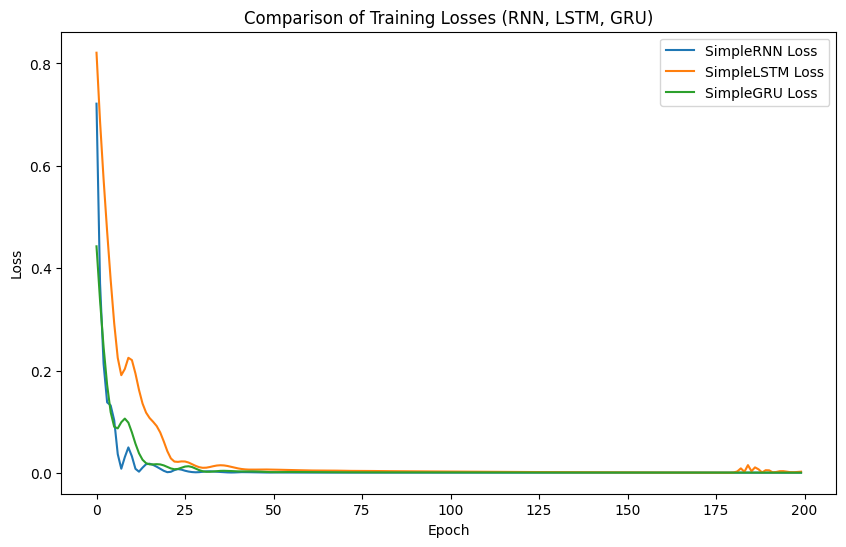

In [53]:
crit_lstm = nn.MSELoss()
optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=0.01)
losses_lstm = []

for epoch in range(200):
    optimizer_lstm.zero_grad()
    out_lstm = lstm_model(X_fib.float())
    loss_lstm = crit_lstm(out_lstm[:, -1, :], Y_fib.float())
    loss_lstm.backward()
    optimizer_lstm.step()
    losses_lstm.append(loss_lstm.item())

crit_gru = nn.MSELoss()
optimizer_gru = optim.Adam(gru_model.parameters(), lr=0.01)
losses_gru = []

for epoch in range(200):
    optimizer_gru.zero_grad()
    out_gru = gru_model(X_fib.float())
    loss_gru = crit_gru(out_gru[:, -1, :], Y_fib.float())
    loss_gru.backward()
    optimizer_gru.step()
    losses_gru.append(loss_gru.item())

plt.figure(figsize=(10, 6))
plt.plot(losses_fib, label='SimpleRNN Loss')
plt.plot(losses_lstm, label='SimpleLSTM Loss')
plt.plot(losses_gru, label='SimpleGRU Loss')
plt.title("Comparison of Training Losses (RNN, LSTM, GRU)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()